# 量子振幅放大（QAA）

量子振幅放大(Quantum Amplitude Amplification，QAA)算法是量子计算中的一种常规算法，它概括了 Grover 著名搜索算法背后的思想，并在许多量子算法中得到应用。简而言之，QAA 使用迭代的方法来系统地增加在给定搜索空间中找到一个或多个目标态的概率。在量子计算机中，QAA 可以用来获得相对于几种经典算法的二次加速[1]。

## QAA 的技术背景

**QAA 的形式化介绍**： 考虑一个酉算符 $\mathcal{A}$ 作用在 $(n+1)$ 个量子比特上[1-4]，如下所示

$$\mathcal{A}|0\rangle_{n+1} = |\psi\rangle = \sqrt{a} |G\rangle |1\rangle + \sqrt{1-a} |B\rangle |0\rangle,$$

其中 $a \in [0,1]$ 是我们希望放大的振幅。令 $\sqrt{a} = \sin(\theta)$，我们可以等价地写成

$$\mathcal{A}|0\rangle_{n+1} = |\psi\rangle = \sin(\theta) |G\rangle |1\rangle + \cos(\theta) |B\rangle |0\rangle.$$

在这里，我们引入了 $n$ 个量子比特的态 $|G\rangle$ 和 $|B\rangle$，分别称为"好"态和"坏"态。态 $|\psi_{1}\rangle = |G\rangle |1\rangle$ 和 $|\psi_{0}\rangle = |B\rangle |0\rangle$ 是原始态 $|\psi\rangle$ 在好子空间 $\mathcal{H}_{1}$ 和坏子空间 $\mathcal{H}_{0}$ 上的投影。注意 $|\psi_{1}\rangle$ 和 $|\psi_{0}\rangle$ 是正交的，即 $\langle \psi_{0}|\psi_{1}\rangle = \langle B|G\rangle \langle 0|1\rangle =0$，因为 $\langle 0|1\rangle =0$。

**QAA 的目标**： 算法的目标是将初始态 $|\psi\rangle \in \mathcal{H}$ 演化为与"好"子空间 $\mathcal{H}_{1}$ 有更高重叠的态，通过放大态的 $|\psi_{1}\rangle$ 分量的振幅来实现。

接下来的放大过程将好态 $|G\rangle$ 的振幅从 $\sin(\theta)$ 提升到 $\sin((2m+1)\theta)$，其中 $2m$ 表示酉算符 $\mathcal{A}$ 的"查询"或应用次数。当 $m=\left\lfloor\frac{\pi}{4\theta}\right\rfloor$ 时，找到"好"结果的概率最大化。

**QAA 的过程**： QAA 并不直接对 $|\psi\rangle$ 进行测量，而是通过应用以下算符 $\mathcal{Q}$ 进行，

$$\mathcal{Q}=\mathcal{A}\mathcal{R}_{0}\mathcal{A}^{\dagger}\mathcal{R}_{B}.$$

其中，$\mathcal{R}_{0}=2|0\rangle_{n+1}\langle 0|-\mathbb{1}$ 是关于 $|0\rangle_{n+1}$ 的反射（保持全零态 $|0\rangle_{n+1}$ 不变，而对所有其他态给出负号），类似地，$\mathcal{R}_{B}=\mathbb{1}-2|G\rangle|1\rangle\langle 1|\langle G|$ 是关于 $|B\rangle|0\rangle$ 的反射，对好态给出负号，因为 $\mathcal{R}_{B}|G\rangle|1\rangle=-1|G\rangle|1\rangle$，而保持坏态 $|B\rangle|0\rangle$ 不变。最后，$\mathcal{A}^{\dagger}$ 表示 $\mathcal{A}$ 的共轭转置。在 $|\psi\rangle=\mathcal{A}|0\rangle_{n+1}$ 上重复应用算符 $\mathcal{Q}$($m$ 次)可得

$$\mathcal{Q}^{m}|\psi\rangle=\mathcal{Q}^{m}\mathcal{A}|0\rangle_{n+1}=\sin((2m+1)\theta)|G\rangle|1\rangle+\cos((2m+1)\theta)|B\rangle|0\rangle.$$

这个等式表明，对于未知参数 $a$ 的小值，重复应用 $Q$（总共涉及 $2m$ 次 $\mathcal{A}$ 的查询）会产生一个态，其中期望的好态的测量概率至少比从 $\mathcal{A}|0\rangle_{n+1}$ 获得的策略大 $4m^{2}$ 倍。这是因为测量好态 $|G\rangle|1\rangle$ 的概率为 $P_{1}=\sin^{2}((2m+1)\theta)\approx(2m+1)^{2}\theta^{2}>4m^{2}\theta^{2}$ 。与之相比，进行 $2m$ 次查询，即对态 $\mathcal{A}|0\rangle_{n+1}$ 的 $2m$ 个副本进行测量，好态的概率只是线性增加 $2m$。这个推理是 QAA 获得二次加速的核心：经过 QAA 后，测量好态的概率随 $m$ 呈二次增长，而不是线性增长，这意味着我们只需要 $O(\sqrt{m})$ 次 $\mathcal{A}$ 的查询就可以达到与经典策略相同的测量 $|G\rangle$ 的概率。具体来说，如果 $(2m+1)\theta\approx\pi/2$ ，我们就把成功概率放大到了 $\sin(...)^{2}\approx1$。 

因为我们假设 $\mathcal{A}$ 是给定的 QAA 的输入，所以我们的目标是找出如何在量子线路中实现 $\mathcal{R}_{B}$、$\mathcal{R}_{0}$ 和 $\mathcal{A}^{\dagger}$ 作为酉算符。接下来的内容将详细展示这个工作。

## QAA过程:

1. __原始状态__：首先，由$\mathcal{A}$制备的原始态 $|\psi\rangle = \mathcal{A}|0\rangle _{n+1} = \sin(\theta) |G\rangle |1\rangle + \cos(\theta) |B\rangle |0\rangle$ 位于由基向量 $|G\rangle |1\rangle$ 和 $|B\rangle |0\rangle$ 张成的二维平面内，在 $|G\rangle |1\rangle$ 轴上有投影 $\sin(\theta)$ 。

2. __关于$|B\rangle |0\rangle$的反射__：然后，我们对 $|B\rangle |0\rangle$ 进行反射，将 $|\psi\rangle$ 变换为 $|\psi'\rangle$ ，保持沿 $|B\rangle |0\rangle$ 方向的投影不变，但在 $|G\rangle |1\rangle$ 分量上增加一个负号。关于 $|B\rangle |0\rangle$ 的反射意味着除 $|B\rangle |0\rangle$ 以外的所有项都会获得负号。因为只有两项，所以只有 $|G\rangle |1\rangle$ 获得负号，这可通过之前定义的算子 $\mathcal{R}_{B} = \mathbb{1} - 2 |G\rangle |1\rangle \langle 1|\langle G|$ 来实现。

3. __关于$|\psi\rangle$的反射__：最后，我们对原始态 $|\psi\rangle$ 进行反射，得到最终态 $|\psi''\rangle$ ，其 $|G\rangle |1\rangle$ 振幅放大为 $\sin(3\theta)$ ，通过绕 $|\psi\rangle$ 旋转增加了 $2\theta$ 角度，叠加在原始角度 $\theta$ 上。关于 $|\psi\rangle$ 的反射意味着除 $|\psi\rangle$ 以外的所有项都会获得负号，可通过应用算子 $\mathcal{R}_{\psi} = 2|\psi\rangle\langle\psi| - \mathbb{1}$ 来实现。利用定义 $|\psi\rangle = \mathcal{A}|\vec{0}\rangle$ 及其逆 $\langle \psi | = \langle \vec{0}|\mathcal{A}^{\dagger}$ ，以及幺正条件 $\mathcal{A}\mathcal{A}^{\dagger}=\mathbb{1}$ ，可以将这个反射重写为 $\mathcal{R}_{\psi} = \mathcal{A}\mathcal{R}_{0}\mathcal{A}^{\dagger}$ ，其中 $\mathcal{R}_{0}=2|\vec{0}\rangle\langle\vec{0}| - \mathbb{1}$ 是关于全零态 $|\vec{0}\rangle$ 的反射，除 $|\vec{0}\rangle$ 以外的所有项都会获得负号。

以上过程完成了QAA的一个循环，即 $\mathcal{Q}$ 的一次应用。总的来说，每次应用 $Q$ 都涉及两次反射，先通过 $|B\rangle |0\rangle$ ，然后通过 $|\psi\rangle$ 。其乘积是一个角度为 $2\theta$ 的旋转。根据以上分析，我们可以将旋转 $\mathcal{Q}$ 写作

$$\mathcal{Q} = \mathcal{R}_{\psi}\mathcal{R}_{B} = \mathcal{A}\mathcal{R}_{0}\mathcal{A}^{\dagger}\mathcal{R}_{B},$$

从而确认了前文的正式定义。重复这一过程， $\mathcal{Q}$ 迭代 $m$ 次后，我们得到广义方程

$$\mathcal{Q}^{m} |\psi\rangle = \sin((2m+1)\theta) |G\rangle |1\rangle + \cos((2m+1)\theta) |B\rangle |0\rangle.$$

__获得量子加速__

为了说明QAA确实提供了量子加速,假设我们用它来查询一个具有$N$个元素和$G$个好元素的未排序数据库。查找好元素的经典算法是查询数据库中的每个元素，直到找到一个好元素。因此，经典解决方案需要 $O(N/G)$ 次查询。量子解决方案是使用态 $1/\sqrt{N}\sum_i|j\rangle$ 对数据库进行叠加查询，其中 $j$ 枚举了数据库的 $N$ 个元素。oracle制备态

$$|\psi\rangle = \sqrt{\frac{G}{N}} |G\rangle |1\rangle + \sqrt{\frac{N-G}{N}} |B\rangle |0\rangle.$$

因此，$\sqrt{a}=\sin(\theta)=\sqrt{G/N}$，对于$\theta \ll 1$的典型情况， $\theta \approx \sqrt{G/N}$ 。

然后，我们应用QAA算法来放大好态的振幅，从而放大获得好结果的概率。为了确保以高概率测量到好结果，我们将Grover迭代器应用 $\left\lfloor\frac{\pi}{4\theta}\right\rfloor=\left\lfloor\frac{\pi}{4}\sqrt{\frac{N}{G}}\right\rfloor$ 次。换句话说，我们只需查询oracle $O(\sqrt{N/G})$ 次，就能以高概率找到搜索问题的好结果。这比经典所需的 $O(N/G)$ 次oracle调用有平方级的改进。


## QAA的线路实现

现在我们对量子振幅放大算法有了直观的理解，剩下的最后一块拼图就是如何用量子电路实际实现反射算子 $\mathcal{R}_{B}$ 和 $\mathcal{R}_{0}$ （因为 $\mathcal{A}$ 是作为量子振幅放大算法问题的输入给出的）。
下面我们不会直接实现 $\mathcal{R}_{0}$ ，而是展示如何实现

$$-\mathcal{R}_{0} = \mathbb{1} - 2|0\rangle_{n+1} \langle 0|,$$

它只对 $|0\rangle_{n+1}$ 产生一个负号，而其他所有态都不受影响。
为了补偿这个负号，我们将展示如何实现整体的幺正算符

$$\mathcal{Q}=\mathcal{A} (-\mathcal{R}_{0}) \mathcal{A}^{\dagger} (-\mathcal{R}_{B}).$$

### 实现 $-\mathcal{R}_{B}$

首先，让我们考虑

$$-\mathcal{R}_{B} = 2 |G\rangle |1\rangle \langle 1|\langle G| - \mathbb{1},$$

这是关于$|G\rangle |1\rangle$的反射，因为 $-\mathcal{R}_{B} |G\rangle |1\rangle = +1|G\rangle |1\rangle$ 且 $-\mathcal{R}_{B} |B\rangle |0\rangle = -1|B\rangle |0\rangle$ 。
这个变换可以通过对(最后一个)辅助量子比特应用 $X_{n+1}Z_{n+1}X_{n+1}$ 来实现。
这样，每当辅助量子比特处于$|0\rangle$态时，我们就得到一个负号。

### 实现 $-\mathcal{R}_{0}$

我们必须实现变换$|0, \dots, 0\rangle \rightarrow -|0, \dots, 0\rangle$，同时保持其他所有态不变。
为此，我们可以翻转所有量子比特(使用单量子比特的$X$门)，对 $|11...1\rangle$ 翻转符号，然后再把量子比特翻转回来。
因此，最后一个需要明确定义的操作是翻转 $|11...1\rangle$ 的符号，这可以用辅助量子比特来完成。
一种可能的方法是使用多重控制的Toffoli门：
首先对每个量子比特应用一个Pauli-$X$门。
然后对所有 $N$ 个我们要测试的量子比特应用 $N+1$ 量子比特的Toffoli门，目标是单个辅助量子比特。
当且仅当所有寄存器量子比特都处于 $|0\rangle$ 态时，辅助量子比特才会翻转到 $|1\rangle$ 态。
然后我们对辅助量子比特应用一个 $Z$ 门，这样每当寄存器的所有量子比特都在 $|0\rangle$ 态时，总波函数就会获得一个负号。
最后，我们通过再次应用 $N+1$ 量子比特的Toffoli门来反计算辅助量子比特。

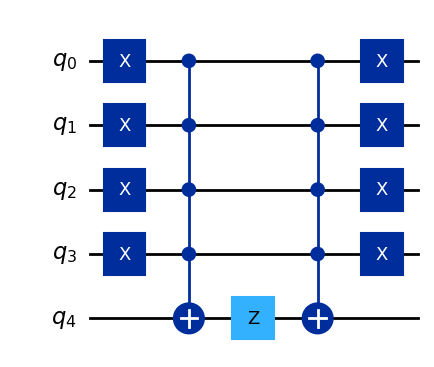

In [1]:
import deepquantum as dq

N=4

cir = dq.QubitCircuit(N+1)
cir.xlayer(list(range(N)))
cir.x(N,list(range(N)))
cir.z(N)
cir.x(N,list(range(N)))
cir.xlayer(list(range(N)))
cir.draw()

## 应用和展望

量子振幅放大技术不仅用于搜索问题，还可以扩展到其他算法中，例如量子机器学习、优化问题和其他决策问题中。随着量子硬件的发展和量子算法的改进，我们可以期待它在未来的量子计算应用中扮演更重要的角色。

## 参考文献

[1] Wikipedia: [Amplitude Amplification](https://en.wikipedia.org/wiki/Amplitude_amplification).

[2] G. Brassard, P. Høyer, "An exact quantum polynomial-time algorithm for Simon's problem", Proceedings of Fifth Israeli Symposium on Theory of Computing and Systems. IEEE Computer Society Press: 12–23, [arXiv:quant-ph/9704027](https://arxiv.org/abs/quant-ph/9704027) (1997). 

[3] G. Brassard, P. Høyer, M. Mosca, A. Tapp, "Quantum Amplitude Amplification and Estimation", [arXiv:quant-ph/0005055](https://arxiv.org/pdf/quant-ph/0005055.pdf) (2000).

[4] Y. Suzuki, S. Uno, R. Raymond, T. Tanaka, T. Onodera, N. Yamamoto, "Amplitude Estimation without Phase Estimation", [arXiv:1904.10246](https://arxiv.org/pdf/1904.10246.pdf) (2019). 